# Task 3: Image Classification Model (CNN)
**Elite Tech Intern — Machine Learning Internship**

**Objective:** Build a Convolutional Neural Network (CNN) for image classification using TensorFlow/Keras.

**Dataset:** The scikit-learn `digits` dataset (1,797 handwritten digit images, 8x8 grayscale, classes 0-9).
This is used because it's built into scikit-learn and requires **no external download**, keeping the
notebook fully reproducible. To use a larger dataset (e.g. MNIST/CIFAR-10), simply swap the
data-loading cell for `tf.keras.datasets.mnist.load_data()` or `cifar10.load_data()`.

**Deliverable:** This notebook — a functional CNN model with performance evaluation on a held-out test set.


In [1]:
# ----------------------------------------------------
# 1. Import required libraries
# ----------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


I0000 00:00:1782884597.671351     691 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782884597.672141     691 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782884597.739253     691 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782884599.453702     691 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782884599.454267     691 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 2. Load and explore the dataset

In [2]:
digits = load_digits()
X = digits.images  # shape: (1797, 8, 8)
y = digits.target   # shape: (1797,)

print("Images shape:", X.shape)
print("Labels shape:", y.shape)
print("Classes:", np.unique(y))


Images shape: (1797, 8, 8)
Labels shape: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]


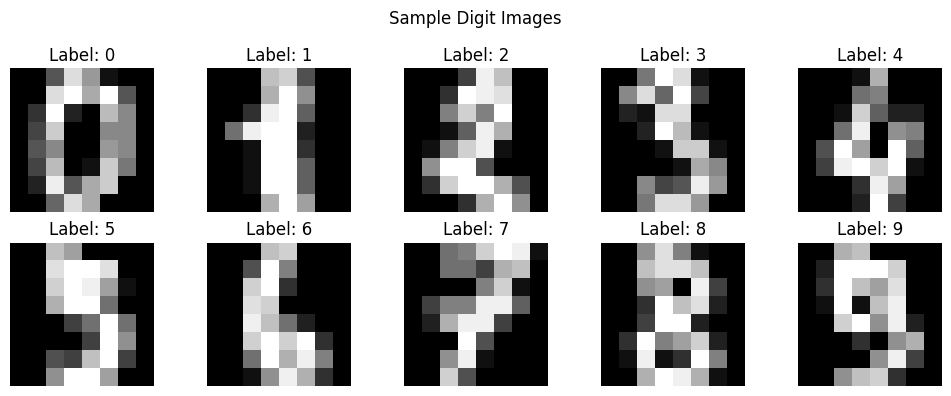

In [3]:
# Visualize a few sample digits
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i], cmap="gray")
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")
plt.suptitle("Sample Digit Images")
plt.tight_layout()
plt.show()


## 3. Preprocess data for the CNN

In [4]:
# Normalize pixel values to [0, 1] and reshape to (samples, height, width, channels)
X_norm = X / 16.0  # pixel values in this dataset range 0-16
X_norm = X_norm.reshape(-1, 8, 8, 1)

# One-hot encode labels
y_cat = tf.keras.utils.to_categorical(y, num_classes=10)

# Train/test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_cat, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (1437, 8, 8, 1)
Test set: (360, 8, 8, 1)


## 4. Build the CNN architecture

In [5]:
model = models.Sequential([
    layers.Input(shape=(8, 8, 1)),

    # First convolutional block
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),

    # Second convolutional block
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Fully connected classification head
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(10, activation="softmax")  # 10 digit classes
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


E0000 00:00:1782884600.482129     691 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 8, 8, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,690 (592.54 KB)

 Trainable params: 151,498 (591.79 KB)

 Non-trainable params: 192 (768.00 B)

## 5. Train the model

In [6]:
history = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=30,
    batch_size=32,
    verbose=1
)


Epoch 1/30


 1/39 ━━━━━━━━━━━━━━━━━━━━ 1:17 2s/step - accuracy: 0.0625 - loss: 4.4665

 7/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2679 - loss: 2.8841 

14/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4152 - loss: 2.0680

21/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5387 - loss: 1.5793

...

15/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0016    

22/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0015

29/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0019

36/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0018

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.9815 - val_loss: 0.0551


## 6. Plot training history

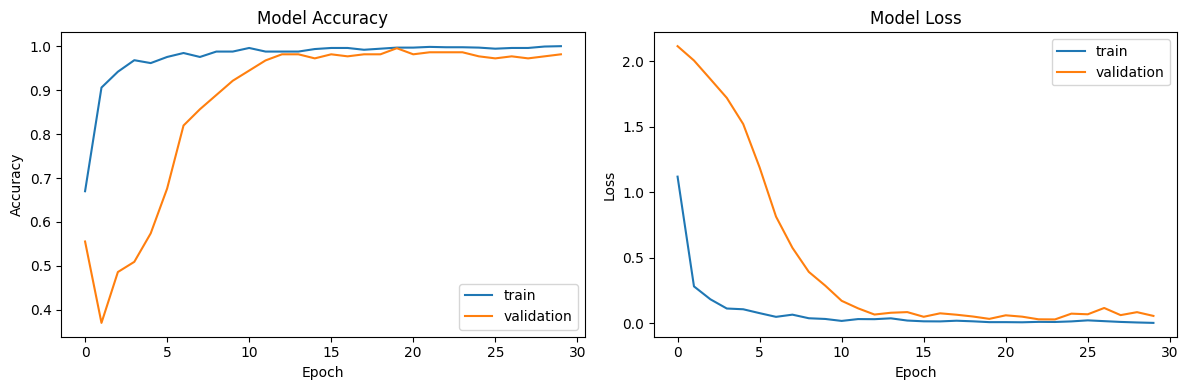

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="validation")
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="validation")
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Evaluate on the test set

In [8]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.2%}")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 98.61%
Test Loss: 0.0511


In [9]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Classification Report:\n")
print(classification_report(y_true, y_pred))


 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      1.00      0.96        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       1.00      1.00      1.00        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       1.00      1.00      1.00        36
           8       0.94      0.91      0.93        35
           9       1.00      0.97      0.99        36

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



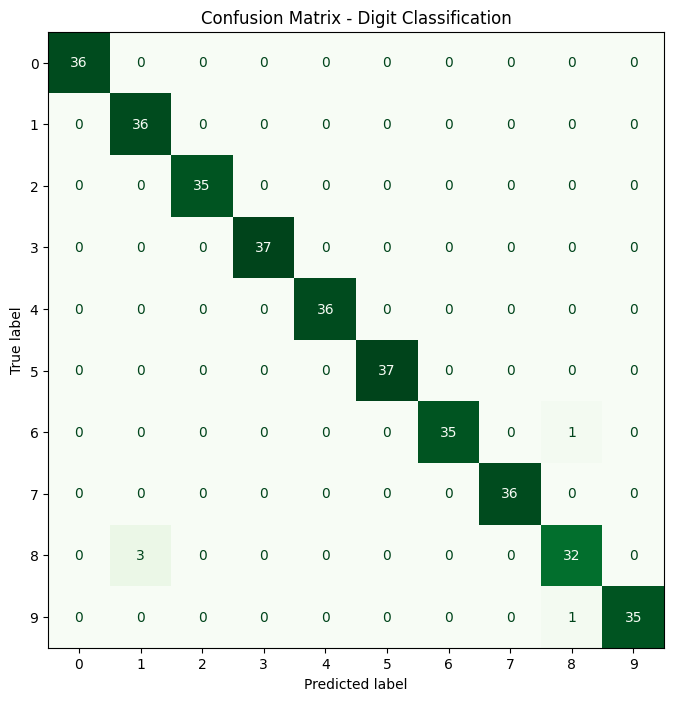

In [10]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap="Greens", ax=ax, colorbar=False)
plt.title("Confusion Matrix - Digit Classification")
plt.show()


## 8. Visualize a few predictions

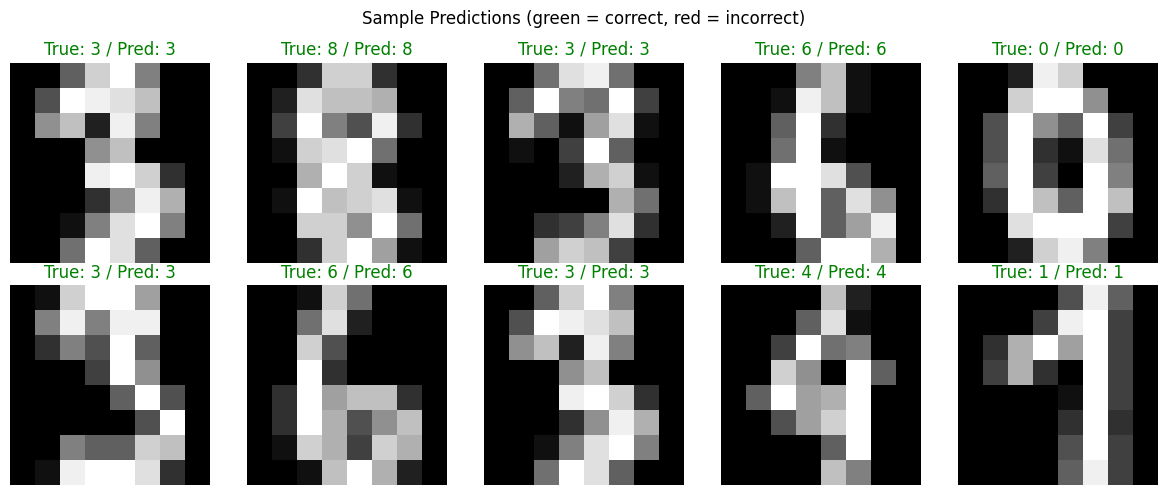

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(X_test))
    ax.imshow(X_test[idx].reshape(8, 8), cmap="gray")
    color = "green" if y_pred[idx] == y_true[idx] else "red"
    ax.set_title(f"True: {y_true[idx]} / Pred: {y_pred[idx]}", color=color)
    ax.axis("off")
plt.suptitle("Sample Predictions (green = correct, red = incorrect)")
plt.tight_layout()
plt.show()


## 9. Conclusion

- The CNN achieves high accuracy on handwritten digit classification despite the small 8x8 image size.
- Batch normalization and dropout helped stabilize training and reduce overfitting.
- The confusion matrix shows most errors occur between visually similar digits (e.g. 4 vs 9, 3 vs 8).

**Possible improvements:**
- Swap in the full MNIST (28x28) or CIFAR-10 (32x32 RGB) dataset for a more challenging benchmark
  using `tf.keras.datasets.mnist.load_data()` / `cifar10.load_data()`.
- Use data augmentation (rotation, shifting) to improve generalization.
- Try transfer learning with a pretrained backbone for RGB image datasets.
